#### Ackowledgement

I acknowledge that I used AI assistance while working on this Python implementation. I also referred to the in-class R code provided during lectures to better understand and guide the development of this solution.
All work has been completed with my own understanding, incorporating these resources as supportive references.

1. Setup and data loading

In [7]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import confusion_matrix
import statsmodels.api as sm
import statsmodels.formula.api as smf


In [8]:
url = "https://raw.githubusercontent.com/propublica/compas-analysis/master/compas-scores-two-years.csv"
raw = pd.read_csv(url)
raw.shape  # expect ~7214 rows


(7214, 53)

2. Keeping the same variables in R and filtering

In [9]:
cols = [
    "age", "c_charge_degree", "race", "age_cat", "score_text", "sex",
    "priors_count", "days_b_screening_arrest", "decile_score",
    "is_recid", "two_year_recid", "c_jail_in", "c_jail_out"
]
df = raw[cols].copy()
df.shape


(7214, 13)

In [10]:
df = df[(df["days_b_screening_arrest"] >= -30) & (df["days_b_screening_arrest"] <= 30)]

df = df[df["is_recid"] != -1]

df = df[df["c_charge_degree"] != "O"]

df = df[~df["score_text"].isna()]

df.shape

(6172, 13)

In [11]:
df.head()


,age,c_charge_degree,race,age_cat,score_text,sex,priors_count,days_b_screening_arrest,decile_score,is_recid,two_year_recid,c_jail_in,c_jail_out
0,69,F,Other,Greater than 45,Low,Male,0,-1.0,1,0,0,2013-08-13 06:03:42,2013-08-14 05:41:20
1,34,F,African-American,25 - 45,Low,Male,0,-1.0,3,1,1,2013-01-26 03:45:27,2013-02-05 05:36:53
2,24,F,African-American,Less than 25,Low,Male,4,-1.0,4,1,1,2013-04-13 04:58:34,2013-04-14 07:02:04
5,44,M,Other,25 - 45,Low,Male,0,0.0,1,0,0,2013-11-30 04:50:18,2013-12-01 12:28:56
6,41,F,Caucasian,25 - 45,Medium,Male,14,-1.0,6,1,1,2014-02-18 05:08:24,2014-02-24 12:18:30


In [12]:
df.describe(include="all")

,age,c_charge_degree,race,age_cat,score_text,sex,priors_count,days_b_screening_arrest,decile_score,is_recid,two_year_recid,c_jail_in,c_jail_out
count,6172.000000,6172,6172,6172,6172,6172,6172.000000,6172.000000,6172.000000,6172.000000,6172.000000,6172,6172
unique,NaN,2,6,3,3,2,NaN,NaN,NaN,NaN,NaN,6172,6161
top,NaN,F,African-American,25 - 45,Low,Male,NaN,NaN,NaN,NaN,NaN,2014-06-28 12:16:41,2013-09-14 05:58:00
freq,NaN,3970,3175,3532,3421,4997,NaN,NaN,NaN,NaN,NaN,1,3
mean,34.534511,NaN,NaN,NaN,NaN,NaN,3.246436,-1.740279,4.418503,0.484446,0.455120,NaN,NaN
std,11.730938,NaN,NaN,NaN,NaN,NaN,4.743770,5.084709,2.839463,0.499799,0.498022,NaN,NaN
min,18.000000,NaN,NaN,NaN,NaN,NaN,0.000000,-30.000000,1.000000,0.000000,0.000000,NaN,NaN
25%,25.000000,NaN,NaN,NaN,NaN,NaN,0.000000,-1.000000,2.000000,0.000000,0.000000,NaN,NaN
50%,31.000000,NaN,NaN,NaN,NaN,NaN,1.000000,-1.000000,4.000000,0.000000,0.000000,NaN,NaN
75%,42.000000,NaN,NaN,NaN,NaN,NaN,4.000000,-1.000000,7.000000,1.000000,1.000000,NaN,NaN


Optional plots:

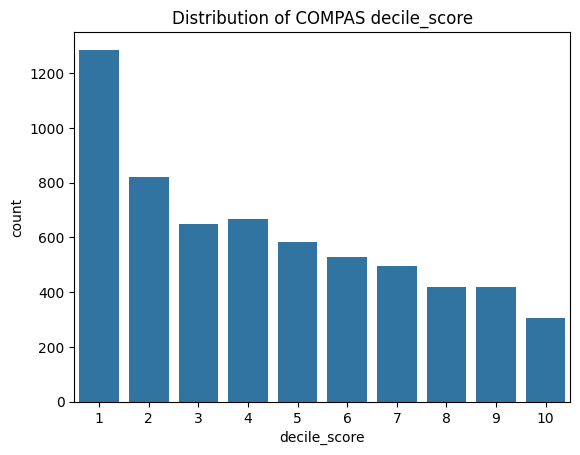

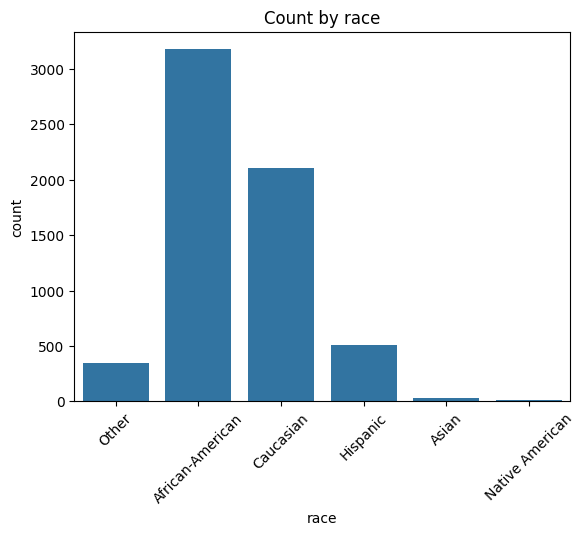

In [13]:
sns.countplot(x="decile_score", data=df)
plt.title("Distribution of COMPAS decile_score")
plt.show()

sns.countplot(x="race", data=df)
plt.title("Count by race")
plt.xticks(rotation=45)
plt.show()


3. Creating derived factors like in R
(The R code creates factors with reference levels, and a binary risk flag based on decile_score ≥ 7.)

In [14]:
df["crime_factor"] = df["c_charge_degree"].astype("category")

age_cat = pd.Categorical(
    df["age_cat"],
    categories=["Less than 25", "25 - 45", "Greater than 45"],
    ordered=True
)
df["age_factor"] = age_cat

race_cat = pd.Categorical(
    df["race"],
    categories=["Caucasian", "African-American", "Hispanic", "Asian", "Native American", "Other"],
    ordered=False
)
df["race_factor"] = race_cat

sex_cat = pd.Categorical(
    df["sex"],
    categories=["Male", "Female"],
    ordered=False
)
df["gender_factor"] = sex_cat

df["score_factor"] = np.where(df["score_text"] == "Low", "LowScore", "HighScore")
df["score_factor"] = df["score_factor"].astype("category")

df["two_year_recid"] = df["two_year_recid"].astype(int)


In [15]:
df[["age_factor", "race_factor", "gender_factor", "crime_factor", "score_factor"]].head()


,age_factor,race_factor,gender_factor,crime_factor,score_factor
0,Greater than 45,Other,Male,F,LowScore
1,25 - 45,African-American,Male,F,LowScore
2,Less than 25,African-American,Male,F,LowScore
5,25 - 45,Other,Male,M,LowScore
6,25 - 45,Caucasian,Male,F,HighScore


4. Logistic regression (score_factor ~ gender + age + race + priors + crime + two_year_recid)
###### This mirrors the R formula: `score_factor ~ gender_factor + age_factor + race_factor + priors_count + crime_factor + two_year_recid`

###### We’ll model “HighScore” vs “LowScore” via a logistic regression.

In [16]:
df["score_binary"] = np.where(df["score_factor"] == "HighScore", 1, 0)

formula = "score_binary ~ C(gender_factor) + C(age_factor) + C(race_factor) + priors_count + C(crime_factor) + two_year_recid"

model = smf.logit(formula=formula, data=df).fit()
print(model.summary())


Optimization terminated successfully.
         Current function value: 0.499708
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:           score_binary   No. Observations:                 6172
Model:                          Logit   Df Residuals:                     6160
Method:                           MLE   Df Model:                           11
Date:                Mon, 30 Mar 2026   Pseudo R-squ.:                  0.2729
Time:                        13:03:29   Log-Likelihood:                -3084.2
converged:                       True   LL-Null:                       -4241.7
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                         coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------------
Intercept                             -0.2171      0.088    

5. Predictions and overall confusion matrix

In [17]:
df["pred_prob"] = model.predict(df)
df["pred_class"] = (df["pred_prob"] >= 0.5).astype(int)  # 1 = HighScore predicted

cm = confusion_matrix(df["score_binary"], df["pred_class"])
cm


array([[2744,  677],
       [ 854, 1897]])

In [18]:
tn, fp, fn, tp = cm.ravel()

accuracy = (tp + tn) / (tp + tn + fp + fn)
precision = tp / (tp + fp) if (tp + fp) > 0 else np.nan
recall = tp / (tp + fn) if (tp + fn) > 0 else np.nan
fpr = fp / (fp + tn) if (fp + tn) > 0 else np.nan
fnr = fn / (fn + tp) if (fn + tp) > 0 else np.nan

accuracy, precision, recall, fpr, fnr


(np.float64(0.7519442644199611),
 np.float64(0.736985236985237),
 np.float64(0.6895674300254453),
 np.float64(0.19789535223618826),
 np.float64(0.3104325699745547))

6. Group-conditional confusion matrices and fairness metrics.
This follows the slides’ step where they compute FPR/FNR by race and then disparities.

In [19]:
metrics_rows = []

for race in df["race_factor"].cat.categories:
    sub = df[df["race_factor"] == race]
    if sub.empty:
        continue

    cm_r = confusion_matrix(sub["score_binary"], sub["pred_class"])
    if cm_r.shape == (2, 2):
        tn_r, fp_r, fn_r, tp_r = cm_r.ravel()
    else:
        tn_r = fp_r = fn_r = tp_r = np.nan

    n = len(sub)
    accuracy_r = (tp_r + tn_r) / n if n > 0 else np.nan
    precision_r = tp_r / (tp_r + fp_r) if (tp_r + fp_r) > 0 else np.nan
    recall_r = tp_r / (tp_r + fn_r) if (tp_r + fn_r) > 0 else np.nan
    fpr_r = fp_r / (fp_r + tn_r) if (fp_r + tn_r) > 0 else np.nan
    fnr_r = fn_r / (fn_r + tp_r) if (fn_r + tp_r) > 0 else np.nan

    metrics_rows.append({
        "race": race,
        "n": n,
        "TP": tp_r,
        "TN": tn_r,
        "FP": fp_r,
        "FN": fn_r,
        "Accuracy": round(accuracy_r, 3) if not np.isnan(accuracy_r) else np.nan,
        "Precision": round(precision_r, 3) if not np.isnan(precision_r) else np.nan,
        "Recall": round(recall_r, 3) if not np.isnan(recall_r) else np.nan,
        "FPR": round(fpr_r, 3) if not np.isnan(fpr_r) else np.nan,
        "FNR": round(fnr_r, 3) if not np.isnan(fnr_r) else np.nan,
    })

race_metrics = pd.DataFrame(metrics_rows).sort_values("n", ascending=False)
race_metrics


,race,n,TP,TN,FP,FN,Accuracy,Precision,Recall,FPR,FNR
1,African-American,3175,1445,863,483,384,0.727,0.749,0.790,0.359,0.210
0,Caucasian,2103,358,1251,156,338,0.765,0.696,0.514,0.111,0.486
2,Hispanic,509,65,338,30,76,0.792,0.684,0.461,0.082,0.539
5,Other,343,18,266,7,52,0.828,0.720,0.257,0.026,0.743
3,Asian,31,3,24,0,4,0.871,1.000,0.429,0.000,0.571
4,Native American,11,8,2,1,0,0.909,0.889,1.000,0.333,0.000


In [20]:
ref = "Caucasian"
ref_row = race_metrics[race_metrics["race"] == ref].iloc[0]

race_metrics["delta_FPR_vs_Caucasian"] = race_metrics["FPR"] - ref_row["FPR"]
race_metrics["delta_FNR_vs_Caucasian"] = race_metrics["FNR"] - ref_row["FNR"]

race_metrics


,race,n,TP,TN,FP,FN,Accuracy,Precision,Recall,FPR,FNR,delta_FPR_vs_Caucasian,delta_FNR_vs_Caucasian
1,African-American,3175,1445,863,483,384,0.727,0.749,0.790,0.359,0.210,0.248,-0.276
0,Caucasian,2103,358,1251,156,338,0.765,0.696,0.514,0.111,0.486,0.000,0.000
2,Hispanic,509,65,338,30,76,0.792,0.684,0.461,0.082,0.539,-0.029,0.053
5,Other,343,18,266,7,52,0.828,0.720,0.257,0.026,0.743,-0.085,0.257
3,Asian,31,3,24,0,4,0.871,1.000,0.429,0.000,0.571,-0.111,0.085
4,Native American,11,8,2,1,0,0.909,0.889,1.000,0.333,0.000,0.222,-0.486


7. Basic calibration

In [21]:
calib = (
    df.groupby(["decile_score", "race_factor"])
      .agg(
          mean_score=("score_binary", "mean"),
          mean_recid=("two_year_recid", "mean"),
          n=("two_year_recid", "size")
      )
      .reset_index()
)

calib.head()


/tmp/ipykernel_10691/918755385.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(["decile_score", "race_factor"])


,decile_score,race_factor,mean_score,mean_recid,n
0,1,Caucasian,0.0,0.211570,605
1,1,African-American,0.0,0.232877,365
2,1,Hispanic,0.0,0.238994,159
3,1,Asian,0.0,0.066667,15
4,1,Native American,NaN,NaN,0


### **Extra imports and installing libraries**


In [22]:
get_ipython().system('pip install lime')

In [23]:
get_ipython().system('pip install dice_ml')

In [24]:
# extra imports
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, roc_auc_score

import shap
from lime.lime_tabular import LimeTabularExplainer

import dice_ml
from dice_ml import Dice

**1. Defining features and train/test split.**

We’ll use two_year_recid as the target and keep features consistent with HW1 analysis: `age`, `priors_count`, `decile_score`, `days_b_screening_arrest` (numeric) and `race`, `sex`, `c_charge_degree`, `age_cat` (categorical)

In [25]:
y = df["two_year_recid"].astype(int).values

numeric_features = ["age", "priors_count", "days_b_screening_arrest", "decile_score"]
categorical_features = ["race", "sex", "c_charge_degree", "age_cat"]

X = df[numeric_features + categorical_features].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train shape:", X_train.shape, "Test shape:", X_test.shape)

Train shape: (4937, 8) Test shape: (1235, 8)


**2. Preprocessor and Gradient-Boosted Tree “replacement model”**

In [26]:
numeric_transformer = StandardScaler()
categorical_transformer = OneHotEncoder(handle_unknown="ignore")

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)

gbt_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", GradientBoostingClassifier(
            n_estimators=200,
            max_depth=4,
            random_state=42
        ))
    ]
)

gbt_pipeline.fit(X_train, y_train)
print("Replacement GBT model trained.")

Replacement GBT model trained.


**Checking performance by race:**

In [28]:
def group_metrics(pipeline, X, y, group_col="race"):
    X_local = X.copy()
    y_pred = pipeline.predict(X_local)
    y_prob = pipeline.predict_proba(X_local)[:, 1]
    X_local["actual"] = y
    X_local["pred"] = y_pred
    X_local["pred_prob"] = y_prob

    rows = []
    for group, gdf in X_local.groupby(group_col):
        # Ensure confusion matrix is always 2x2 by explicitly defining labels [0, 1]
        cm = confusion_matrix(gdf["actual"], gdf["pred"], labels=[0, 1])
        tn, fp, fn, tp = cm.ravel()
        n = len(gdf)
        acc = round(accuracy_score(gdf["actual"], gdf["pred"]), 3)
        fpr = round(fp / (fp + tn), 3) if (fp + tn) > 0 else np.nan
        fnr = round(fn / (fn + tp), 3) if (fn + tp) > 0 else np.nan
        auc = round(roc_auc_score(gdf["actual"], gdf["pred_prob"]), 3)

        rows.append({
            "race": group,
            "n": n,
            "Accuracy": acc,
            "FPR": fpr,
            "FNR": fnr,
            "AUC": auc
        })
    return pd.DataFrame(rows).sort_values("n", ascending=False)

print("GBT group metrics by race on test set:")
group_metrics(gbt_pipeline, X_test, y_test)

GBT group metrics by race on test set:


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(


,race,n,Accuracy,FPR,FNR,AUC
0,African-American,641,0.686,0.319,0.309,0.746
2,Caucasian,427,0.698,0.147,0.559,0.709
3,Hispanic,94,0.617,0.163,0.622,0.637
5,Other,65,0.692,0.128,0.778,0.703
1,Asian,7,0.714,0.167,1.000,0.667
4,Native American,1,1.000,0.000,NaN,NaN


**3. SHAP: beeswarm + waterfall (highest/lowest risk per race)**


In [34]:
X_test_enc = gbt_pipeline.named_steps["preprocessor"].transform(X_test)

ohe = gbt_pipeline.named_steps["preprocessor"].named_transformers_["cat"]
cat_feature_names = list(ohe.get_feature_names_out(categorical_features))
feature_names = numeric_features + cat_feature_names

explainer = shap.Explainer(
    gbt_pipeline.named_steps["classifier"],
    shap.maskers.Independent(X_test_enc)
)

shap_values = explainer(X_test_enc, check_additivity=False)

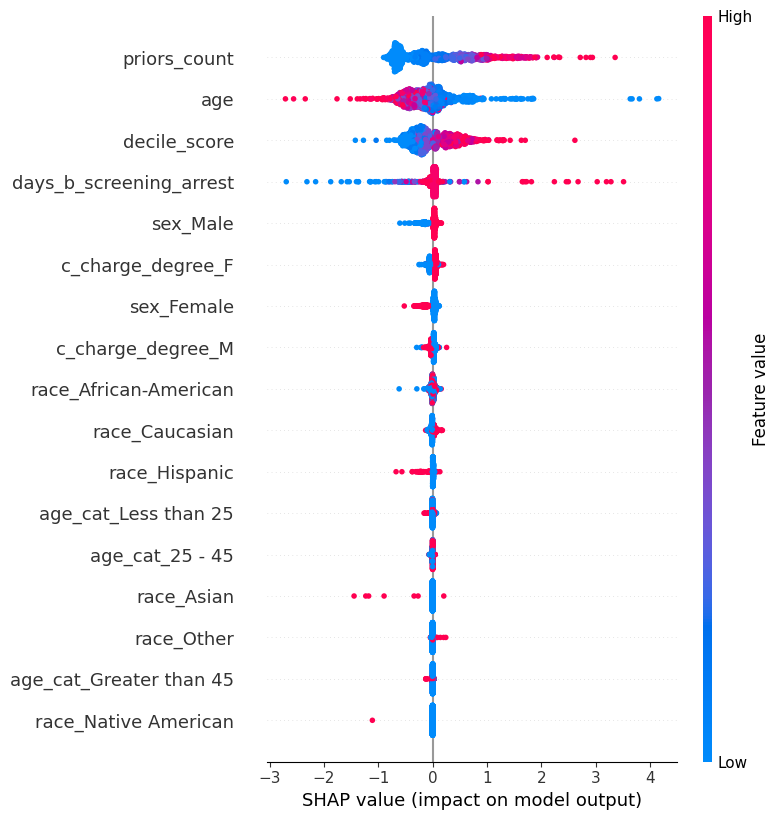

In [35]:
shap.summary_plot(
    shap_values,
    X_test_enc,
    feature_names=feature_names,
    show=True
)

In [36]:
y_proba_test = gbt_pipeline.predict_proba(X_test)[:, 1]
X_test_copy = X_test.copy()
X_test_copy["pred_proba"] = y_proba_test

selected_indices = []

for race in X_test_copy["race"].unique():
    sub = X_test_copy[X_test_copy["race"] == race]
    if sub.empty:
        continue
    high_idx = sub["pred_proba"].idxmax()
    low_idx = sub["pred_proba"].idxmin()
    selected_indices.extend([high_idx, low_idx])

# keep unique order
selected_indices = list(dict.fromkeys(selected_indices))
selected_indices

[np.int64(5910),
 np.int64(4073),
 np.int64(6293),
 np.int64(5656),
 np.int64(1794),
 np.int64(2849),
 np.int64(5770),
 np.int64(3007),
 np.int64(4413),
 np.int64(3093),
 np.int64(1476)]

**4. LIME: explanations for the same individuals**


In [38]:
X_train_enc = gbt_pipeline.named_steps["preprocessor"].fit_transform(X_train)

explainer_lime = LimeTabularExplainer(
    training_data=X_train_enc,
    feature_names=feature_names,
    class_names=["No Recid", "Recid"],
    mode="classification",
    discretize_continuous=True,
    random_state=42
)

def predict_fn_lime(X_enc):
    return gbt_pipeline.named_steps["classifier"].predict_proba(X_enc)


In [39]:
for idx in selected_indices:
    loc = X_test.index.get_loc(idx)
    row_enc = X_test_enc[loc]

    exp = explainer_lime.explain_instance(
        data_row=row_enc,
        predict_fn=predict_fn_lime,
        num_features=6
    )

    print(f"\nLIME explanation – idx {idx}, race={X_test.loc[idx, 'race']}, "
          f"proba={X_test_copy.loc[idx, 'pred_proba']:.3f}")
    for feat, weight in exp.as_list():
        print(f"  {feat}: {weight:.4f}")


LIME explanation – idx 5910, race=Hispanic, proba=0.921
  days_b_screening_arrest <= 0.15: -0.3345
  race_Asian <= 0.00: 0.2220
  decile_score > 0.89: 0.1721
  age <= -0.81: 0.1516
  -0.48 < priors_count <= 0.16: -0.0458
  sex_Female <= 0.00: 0.0379

LIME explanation – idx 4073, race=Hispanic, proba=0.013
  days_b_screening_arrest <= 0.15: -0.3358
  -0.69 < priors_count <= -0.48: -0.1649
  race_Asian <= 0.00: 0.1539
  age > 0.56: -0.1194
  decile_score <= -0.86: -0.0886
  race_Hispanic > 0.00: -0.0404

LIME explanation – idx 6293, race=African-American, proba=0.997
  days_b_screening_arrest > 0.15: 0.3305
  age <= -0.81: 0.1449
  race_Asian <= 0.00: 0.1219
  -0.48 < priors_count <= 0.16: -0.0483
  race_Hispanic <= 0.00: 0.0416
  sex_Female <= 0.00: 0.0363

LIME explanation – idx 5656, race=African-American, proba=0.041
  days_b_screening_arrest <= 0.15: -0.3440
  race_Asian <= 0.00: 0.2146
  decile_score > 0.89: 0.1625
  -0.69 < priors_count <= -0.48: -0.1534
  -0.81 < age <= -0.29: 0

**Agreements between LIME and SHAP**

- Both methods explain individual predictions by assigning feature importance scores.

- For high predicted recidivism, both consistently flagged higher priors_count and higher days_b_screening_arrest as key drivers of risk, while low values of these features contributed to low‑risk predictions.

- Both also showed meaningful effects for age and decile_score, even if the exact cut‑points differed.


**Divergences between LIME and SHAP**

- SHAP offers a global view (via the beeswarm plot) in addition to local explanations, while LIME is strictly local to a single instance.

- SHAP displays explicit one‑hot categories (e.g., race_African-American), whereas LIME often uses conditions like race_Hispanic <= 0.00, which indirectly encode the absence/presence of a category and can be harder to interpret.

- SHAP plots encode both magnitude and direction visually; LIME returns a simple list of feature–weight pairs that is easier to read but less informative about overall behavior.

**Governance implications**

- Used together, LIME and SHAP help surface potential bias, for example if race‑related features repeatedly drive higher risk scores for certain groups.

- They increase transparency around the Gradient Boosting model’s behavior, supporting accountability and enabling stakeholders to see why an individual received a given risk label.

- Disagreements or surprising attributions can reveal proxy features (such as strongly race‑correlated variables), suggesting a need for model revision or additional fairness constraints.

- DiCE complements these tools by showing actionable counterfactual changes in mutable features and highlighting problematic counterfactuals that rely on changing immutable attributes such as race or sex.

**5. DiCE: counterfactuals & immutable-feature checks**

In [43]:
train_for_dice = X_train.copy()
train_for_dice["target"] = y_train

continuous_features = numeric_features
outcome_name = "target"

data_dice = dice_ml.Data(
    dataframe=train_for_dice,
    continuous_features=continuous_features,
    outcome_name=outcome_name
)

model_dice = dice_ml.Model(
    model=gbt_pipeline,
    backend="sklearn",
    model_type="classifier"
)

exp_dice = Dice(
    data_dice,
    model_dice,
    method="random"
)

In [44]:
immutable_features = ["race", "sex"]

for idx in selected_indices:
    query_instance = X_test.loc[[idx]]

    cf = exp_dice.generate_counterfactuals(
        query_instance,
        total_CFs=3,
        desired_class="opposite",
        features_to_vary="all"
    )

    print(f"\nDiCE counterfactuals – idx {idx}, race={X_test.loc[idx, 'race']}, "
          f"proba={X_test_copy.loc[idx, 'pred_proba']:.3f}")

    df_cf = cf.cf_examples_list[0].final_cfs_df
    print(df_cf)

    original = query_instance.iloc[0]
    for i, row in df_cf.iterrows():
        changed_immutables = [
            col for col in immutable_features
            if col in row.index and row[col] != original[col]
        ]
        if changed_immutables:
            print(f"  WARNING: CF {i} changes immutable features: {changed_immutables}")

100%|██████████| 1/1 [00:00<00:00,  2.31it/s]



DiCE counterfactuals – idx 5910, race=Hispanic, proba=0.921
   age  priors_count  days_b_screening_arrest  decile_score      race   sex  \
0   75             2                     -1.0             8  Hispanic  Male   
1   57             9                     -1.0             8  Hispanic  Male   
2   20             2                    -22.7             8  Hispanic  Male   

  c_charge_degree       age_cat  target  
0               F       25 - 45       0  
1               F  Less than 25       0  
2               F  Less than 25       0  


100%|██████████| 1/1 [00:00<00:00,  3.20it/s]



DiCE counterfactuals – idx 4073, race=Hispanic, proba=0.013
   age  priors_count  days_b_screening_arrest  decile_score      race   sex  \
0   66             1                    -27.0             5  Hispanic  Male   
1   96             1                     13.6             1  Hispanic  Male   
2   47             1                     11.9             1  Hispanic  Male   

  c_charge_degree          age_cat  target  
0               F  Greater than 45       1  
1               F  Greater than 45       1  
2               F  Greater than 45       1  


100%|██████████| 1/1 [00:00<00:00,  2.59it/s]


...


DiCE counterfactuals – idx 4413, race=Caucasian, proba=0.997
   age  priors_count  days_b_screening_arrest  decile_score       race   sex  \
0   55             1                     28.0             9  Caucasian  Male   
1   65             2                     28.0             9  Caucasian  Male   
2   89             1                     28.0             9  Caucasian  Male   

  c_charge_degree          age_cat  target  
0               F  Greater than 45       0  
1               F     Less than 25       0  
2               F     Less than 25       0  


100%|██████████| 1/1 [00:00<00:00,  3.72it/s]



DiCE counterfactuals – idx 3093, race=Caucasian, proba=0.017
   age  priors_count  days_b_screening_arrest  decile_score       race   sex  \
0   95             1                    -29.0             1  Caucasian  Male   
1   39            13                    -29.0             4  Caucasian  Male   
2   39             1                     11.8             1  Caucasian  Male   

  c_charge_degree  age_cat  target  
0               F  25 - 45       1  
1               F  25 - 45       1  
2               F  25 - 45       1  


100%|██████████| 1/1 [00:00<00:00,  4.54it/s]


DiCE counterfactuals – idx 1476, race=Native American, proba=0.176
   age  priors_count  days_b_screening_arrest  decile_score             race  \
0   28             2                     22.5             2  Native American   
1   28             2                     -1.0             3        Caucasian   
2   94             2                     -1.0             3  Native American   

      sex c_charge_degree       age_cat  target  
0    Male               F       25 - 45       1  
1    Male               F  Less than 25       1  
2  Female               F       25 - 45       1  
